# Librerias

In [1]:
# Manejo de archivos Pandas
import pandas as pd

# Manejo de matrices
import numpy as np

# División de los datos en entrenamiento y testing
from sklearn.model_selection import train_test_split

# Metricas
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

# Metricas bonitas
from yellowbrick.classifier import confusion_matrix as  cm
from yellowbrick.classifier import classification_report as cr
from yellowbrick.classifier.rocauc import roc_auc
from yellowbrick.classifier import class_prediction_error

# Herramientas
## Encoder, paso de variables categóricas a numéricas
from sklearn.preprocessing import LabelEncoder
## Para preprocesar las features
from sklearn import preprocessing

#Balance de clases
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.over_sampling import KMeansSMOTE
from imblearn.over_sampling import SVMSMOTE
from imblearn.over_sampling import SMOTEN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import ClusterCentroids
from imblearn.under_sampling import NearMiss

# Visualización y gráficos
import seaborn as sns
import matplotlib.pyplot as plt

# PCA
from sklearn.decomposition import PCA

# Aprendizajae NO supervisado
## Hacer K-Means
from sklearn.cluster import KMeans
## Hacer el dendograma de la agrupación jerárquica
from scipy.cluster.hierarchy import dendrogram, linkage
## Hacer las predicciones con agrupación jerárquica
from sklearn.cluster import AgglomerativeClustering

# Aprendizaje supervisado
## Algoritmos de ML para clasificación (13)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
## Algoritmos de ML para regresión (10)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.ensemble import ExtraTreesRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor

# Ajuste de hiperparámetros
from sklearn.model_selection import GridSearchCV

# Importancia de características
from yellowbrick.model_selection import FeatureImportances

# Guardar y cargar modelos
import joblib

# Filtrar advertencias
import warnings
warnings.filterwarnings('ignore')

# Lectura del dataset

In [4]:
# Leer el dataset
df = pd.read_csv("BDParkinson_Prediction.csv")

# División en datos de entrenamiento y testing

In [5]:
# Obtener las features
features = df.drop(['CLASS'], axis=1)
features.head()

,VAR1,VAR2,VAR3,VAR4,VAR5,VAR6
0,0.624731,0.135424,0.0,0.675282,0.182203,0.962960
1,0.647223,0.136211,0.0,0.679511,0.195903,0.987387
2,0.706352,0.187593,0.0,0.632989,0.244884,0.991182
3,0.680291,0.192076,0.0,0.651786,0.233528,0.991857
4,0.660104,0.161131,0.0,0.677162,0.209531,0.991066


In [6]:
# Obtener los labels
labels = df['CLASS']
labels.head()

0    Class_1
1    Class_1
2    Class_1
3    Class_1
4    Class_1
Name: CLASS, dtype: object

In [7]:
# Separación de la data, con un 20% para testing, y 80% para entrenamiento
X_train, X_test, y_train, y_test = train_test_split(features, labels,
                                                    test_size=0.20, random_state=1, stratify=labels)

In [8]:
# Verificacion de la cantidad de datos para entrenamiento y para testing
print("y_train labels unique:",np.unique(y_train, return_counts=True))
print("y_test labels unique: ",np.unique(y_test, return_counts=True))

y_train labels unique: (array(['Class2', 'Class_1', 'Class_3', 'Class_4'], dtype=object), array([100, 100, 100, 100]))
y_test labels unique:  (array(['Class2', 'Class_1', 'Class_3', 'Class_4'], dtype=object), array([25, 25, 25, 25]))


# Aprendizaje supervisado

## Clasificación

In [9]:
# Cargamos el modelo KNN sin entrenar
model_KNN = KNeighborsClassifier(n_neighbors=3)
# Entrenamos el modelo KNN
model_KNN.fit(X_train, y_train)
# Obtenemos la métrica lograda
model_KNN.score(X_test, y_test)

1.0

In [12]:
# Crear los modelos
model_DT  = DecisionTreeClassifier(random_state=0)
model_B   = BaggingClassifier(random_state=0)
model_RF  = RandomForestClassifier(random_state=0)
model_AB  = AdaBoostClassifier(random_state=0)
model_SVM = SVC(random_state=0)
model_ET  = ExtraTreesClassifier(random_state=0)
model_XGB = XGBClassifier(random_state=0)
model_LR  = LogisticRegression(random_state=0, max_iter=200)
model_GB  = GradientBoostingClassifier(random_state=0)


In [13]:
# Ajustar los modelos a la data de entrenamiento
model_DT.fit(X_train, y_train)
model_B.fit(X_train, y_train)
model_RF.fit(X_train, y_train)
model_AB.fit(X_train, y_train)
model_SVM.fit(X_train, y_train)
model_ET.fit(X_train, y_train)
#model_XGB.fit(X_train, y_train)
model_LR.fit(X_train, y_train)
model_GB.fit(X_train, y_train)


GradientBoostingClassifier(random_state=0)

In [14]:
# Predecir y obtener el accuracy
print("DT, Accuracy: ", model_DT.score(X_test, y_test))
print("B, Accuracy: ",  model_B.score(X_test, y_test))
print("RF, Accuracy: ", model_RF.score(X_test, y_test))
print("AB, Accuracy: ", model_AB.score(X_test, y_test))
print("SVM, Accuracy: ",model_SVM.score(X_test, y_test))
print("ET, Accuracy: ", model_ET.score(X_test, y_test))
#print("XGB, Accuracy: ",model_XGB.score(X_test, y_test))
print("LR, Accuracy: ", model_LR.score(X_test, y_test))
print("GB, Accuracy: ", model_GB.score(X_test, y_test))


DT, Accuracy:  0.99
B, Accuracy:  0.99
RF, Accuracy:  0.97
AB, Accuracy:  0.96
SVM, Accuracy:  0.97
ET, Accuracy:  0.99
LR, Accuracy:  0.97
GB, Accuracy:  0.98


## Regresión

In [15]:
# Seleccionando datos para hacer regresión
## Train
X_train_reg = X_train.drop(['VAR5'], axis=1)
y_train_reg = X_train['VAR5']

## Test
X_test_reg = X_test.drop(['VAR5'], axis=1)
y_test_reg = X_test['VAR5']


<Axes: ylabel='VAR5'>

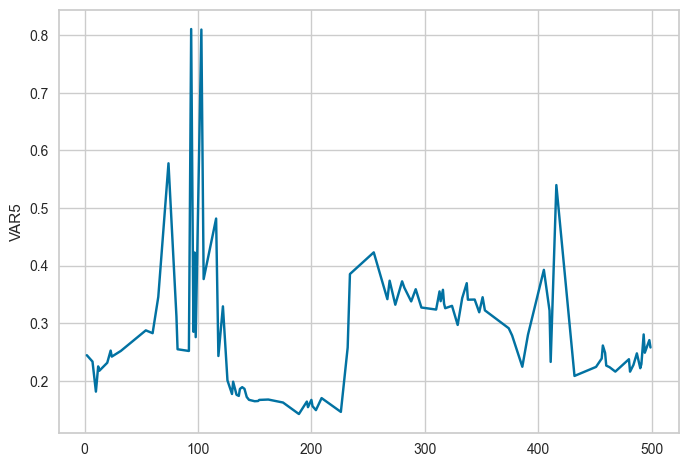

In [16]:
# Gráfica de la variable objetivo
sns.lineplot(data=y_test_reg)

In [17]:
# Cargamos el modelo KNN sin entrenar
model_KNNr = KNeighborsRegressor(n_neighbors=3)

# Entrenamos el modelo KNN
model_KNNr.fit(X_train_reg, y_train_reg)

# Obtenemos la métrica lograda
model_KNNr.score(X_test_reg, y_test_reg)

0.9631421177334887

<Axes: ylabel='VAR5'>

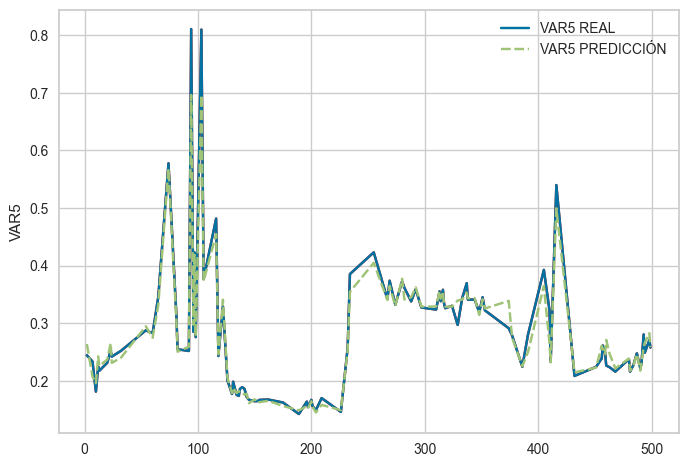

In [18]:
# Gráfica de la variable objetivo real
sns.lineplot(data=y_test_reg,c='r')

# Gráfica de la variable objetivo predicción
y_pred_reg = model_KNNr.predict(X_test_reg)
y_pred_reg = pd.DataFrame(y_pred_reg).set_index(y_test_reg.index)

# Creando un dataframe 2 columnas con variable real y la predicción
df_test_real_pred = pd.concat([y_test_reg,y_pred_reg],axis=1)
df_test_real_pred.rename(columns={'VAR5':'VAR5 REAL',
                        0:'VAR5 PREDICCIÓN'},inplace=True)

sns.lineplot(data=df_test_real_pred)

In [19]:
# Crear los modelos
model_DTr  = DecisionTreeRegressor()
model_Br   = BaggingRegressor()
model_RFr  = RandomForestRegressor()
model_ABr  = AdaBoostRegressor()
model_SVMr = SVR()
model_ETr  = ExtraTreesRegressor()
model_XGBr = XGBRegressor()
model_Lr   = LinearRegression()
model_GBr  = GradientBoostingRegressor()


In [20]:
# Ajustar los modelos a la data de entrenamiento
model_DTr.fit(X_train_reg, y_train_reg)
model_Br.fit(X_train_reg, y_train_reg)
model_RFr.fit(X_train_reg, y_train_reg)
model_ABr.fit(X_train_reg, y_train_reg)
model_SVMr.fit(X_train_reg, y_train_reg)
model_ETr.fit(X_train_reg, y_train_reg)
model_XGBr.fit(X_train_reg, y_train_reg)
model_Lr.fit(X_train_reg, y_train_reg)
model_GBr.fit(X_train_reg, y_train_reg)


GradientBoostingRegressor()

In [21]:
# Predecir y obtener el coeficiente de determinación
print("DTr: ",model_DTr.score(X_test_reg, y_test_reg))
print("Br: ",model_Br.score(X_test_reg, y_test_reg))
print("RFr: ",model_RFr.score(X_test_reg, y_test_reg))
print("ABr: ",model_ABr.score(X_test_reg, y_test_reg))
print("SVMr: ",model_SVMr.score(X_test_reg, y_test_reg))
print("ETr: ",model_ETr.score(X_test_reg, y_test_reg))
print("XGBr: ",model_XGBr.score(X_test_reg, y_test_reg))
print("Lr: ",model_Lr.score(X_test_reg, y_test_reg))
print("GBr: ",model_GBr.score(X_test_reg, y_test_reg))

DTr:  0.9323534063188601
Br:  0.9312595679462381
RFr:  0.9495772966988217
ABr:  0.920951465592205
SVMr:  0.5280872992079053
ETr:  0.9683534902009409
XGBr:  0.948858853029048
Lr:  0.7546713332247559
GBr:  0.9457776034345439


# Optimización de modelos de ML

In [22]:
# Modelo sin ajuste de hiperparámetros
model_SVM = SVC(random_state=0)
model_SVM.fit(X_train, y_train)
print("SVM, Accuracy: ",model_SVM.score(X_test, y_test))

# Metricas: matriz de confusión y reporte de clasificación
y_pred=model_SVM.predict(X_test)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

SVM, Accuracy:  0.97
[[24  0  1  0]
 [ 0 25  0  0]
 [ 0  0 25  0]
 [ 0  0  2 23]]
              precision    recall  f1-score   support

      Class2       1.00      0.96      0.98        25
     Class_1       1.00      1.00      1.00        25
     Class_3       0.89      1.00      0.94        25
     Class_4       1.00      0.92      0.96        25

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [23]:
# Definimos el modelo que se desea tunear
model_SVM = SVC(random_state=0)

# Se definen los hiperparámetros
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}

# Se crea la grilla con los hiperparámetros
grid = GridSearchCV(model_SVM,param_grid,cv=3,verbose=3)

# Se ejecuta la grilla con el modelo
grid.fit(X_train,y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV 1/3] END ....................C=0.1, gamma=1;, score=0.963 total time=   0.0s
[CV 2/3] END ....................C=0.1, gamma=1;, score=0.947 total time=   0.0s
[CV 3/3] END ....................C=0.1, gamma=1;, score=0.902 total time=   0.0s
[CV 1/3] END ..................C=0.1, gamma=0.1;, score=0.493 total time=   0.0s
[CV 2/3] END ..................C=0.1, gamma=0.1;, score=0.722 total time=   0.0s
[CV 3/3] END ..................C=0.1, gamma=0.1;, score=0.902 total time=   0.0s
[CV 1/3] END .................C=0.1, gamma=0.01;, score=0.493 total time=   0.0s
[CV 2/3] END .................C=0.1, gamma=0.01;, score=0.722 total time=   0.0s
[CV 3/3] END .................C=0.1, gamma=0.01;, score=0.647 total time=   0.0s
[CV 1/3] END ................C=0.1, gamma=0.001;, score=0.493 total time=   0.0s
[CV 2/3] END ................C=0.1, gamma=0.001;, score=0.722 total time=   0.0s
[CV 3/3] END ................C=0.1, gamma=0.001;

GridSearchCV(cv=3, estimator=SVC(random_state=0),
             param_grid={'C': [0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001]},
             verbose=3)

In [24]:
# Ver el mejor modelo encontrado
print(grid.best_estimator_)

SVC(C=100, gamma=1, random_state=0)


In [25]:
# Predecir usando los mejores hiperparámetros
grid_predictions = grid.predict(X_test)

# Metricas: matriz de confusión y reporte de clasificación
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))

[[25  0  0  0]
 [ 0 25  0  0]
 [ 0  0 25  0]
 [ 0  0  0 25]]
              precision    recall  f1-score   support

      Class2       1.00      1.00      1.00        25
     Class_1       1.00      1.00      1.00        25
     Class_3       1.00      1.00      1.00        25
     Class_4       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [26]:
# Modelo con los hiperparámetros encontrados con GridSearch
model_SVM = SVC(C=100, gamma=1, random_state=0)
model_SVM.fit(X_train, y_train)
print("SVM, Accuracy: ", model_SVM.score(X_test, y_test))

SVM, Accuracy:  1.0


# Optimización de KNN

In [27]:
knn=KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=10)

In [28]:
y_pred_knn=knn.predict(X_test)

In [29]:
# Metricas: matriz de confusión y reporte de clasificación
print(confusion_matrix(y_test,y_pred_knn))
print(classification_report(y_test,y_pred_knn))

[[24  0  1  0]
 [ 0 25  0  0]
 [ 0  0 25  0]
 [ 0  0  0 25]]
              precision    recall  f1-score   support

      Class2       1.00      0.96      0.98        25
     Class_1       1.00      1.00      1.00        25
     Class_3       0.96      1.00      0.98        25
     Class_4       1.00      1.00      1.00        25

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [30]:
# Definimos el modelo que se desea tunear
knn=KNeighborsClassifier()

# Se definen los hiperparámetros
param_grid = {'n_neighbors': [1,2,3,4,5,6,7,8,9,10]}

# Se crea la grilla con los hiperparámetros
grid = GridSearchCV(knn,param_grid,cv=3,verbose=3)

# Se ejecuta la grilla con el modelo
grid.fit(X_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[CV 1/3] END .....................n_neighbors=1;, score=0.985 total time=   0.0s
[CV 2/3] END .....................n_neighbors=1;, score=0.992 total time=   0.0s
[CV 3/3] END .....................n_neighbors=1;, score=0.977 total time=   0.0s
[CV 1/3] END .....................n_neighbors=2;, score=0.985 total time=   0.0s
[CV 2/3] END .....................n_neighbors=2;, score=0.992 total time=   0.0s
[CV 3/3] END .....................n_neighbors=2;, score=0.977 total time=   0.0s
[CV 1/3] END .....................n_neighbors=3;, score=0.993 total time=   0.0s
[CV 2/3] END .....................n_neighbors=3;, score=1.000 total time=   0.0s
[CV 3/3] END .....................n_neighbors=3;, score=0.985 total time=   0.0s
[CV 1/3] END .....................n_neighbors=4;, score=0.993 total time=   0.0s
[CV 2/3] END .....................n_neighbors=4;, score=0.992 total time=   0.0s
[CV 3/3] END .....................n_neighbors=4;

GridSearchCV(cv=3, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]},
             verbose=3)

In [31]:
# Ver el mejor modelo encontrado
print(grid.best_estimator_)

KNeighborsClassifier(n_neighbors=3)


In [32]:
# Predecir usando los mejores hiperparámetros
grid_predictions = grid.predict(X_test)

# Metricas: matriz de confusión y reporte de clasificación
print(confusion_matrix(y_test,grid_predictions))
print(classification_report(y_test,grid_predictions))

[[25  0  0  0]
 [ 0 25  0  0]
 [ 0  0 25  0]
 [ 0  0  0 25]]
              precision    recall  f1-score   support

      Class2       1.00      1.00      1.00        25
     Class_1       1.00      1.00      1.00        25
     Class_3       1.00      1.00      1.00        25
     Class_4       1.00      1.00      1.00        25

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



# Importancia de características

In [33]:
for i in range(len(labels)):
  if labels[i]=="Class_1":
    labels[i]=0
  if labels[i]=="Class2":
    labels[i]=1
  if labels[i]=="Class_3":
    labels[i]=2
  if labels[i]=="Class_4":
    labels[i]=3


In [34]:
X_train, X_test, y_train, y_test = train_test_split(features, labels,
                                                    test_size=0.20, random_state=1, stratify=labels)

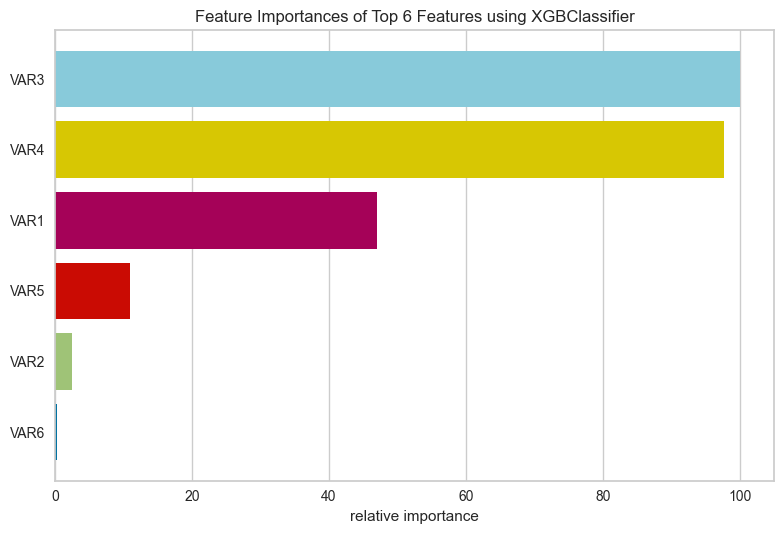

<Axes: title={'center': 'Feature Importances of Top 6 Features using XGBClassifier'}, xlabel='relative importance'>

In [35]:
# Definir el algoritmo de ML
model = XGBClassifier()
model.fit(X_train, y_train)

# Mostrar la importancia de características
viz = FeatureImportances(model, topn=6)
viz.fit(X_train, y_train)
viz.show()

In [36]:
feature_importances=pd.DataFrame({'features':features.columns,'feature_importance':model.feature_importances_})
feature_importances.sort_values('feature_importance',ascending=False)[:6]

,features,feature_importance
2,VAR3,0.386854
3,VAR4,0.378015
0,VAR1,0.182105
4,VAR5,0.042387
1,VAR2,0.009319
5,VAR6,0.001321


In [37]:
from sklearn.utils.multiclass import type_of_target
target_type = type_of_target(y_train[:])
print("Type of target:", target_type)
y_train= y_train[:].astype(int)
y_test=y_test[:].astype(int)

Type of target: unknown


In [38]:
model = SVC(kernel="linear",random_state=0)
model.fit(X_train, y_train)
feature_importance=pd.DataFrame({'feature':list(features.columns),'feature_importance':[abs(i) for i in model.coef_[0]]})
feature_importance.sort_values('feature_importance',ascending=False)[:20]

,feature,feature_importance
5,VAR6,1.567156
2,VAR3,1.087132
1,VAR2,0.735251
3,VAR4,0.217552
4,VAR5,0.217250
0,VAR1,0.063192
